In [2]:
from Utilities_copy import extract_and_filter_mass

x=extract_and_filter_mass('/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH25_LH_2017.root', "Events")

/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


<ValueView mu=25.445014045316324 sigma=2.734145908558211>
chi2 = 2102.584
ndof = 37.0
chi2/ndof = 56.827
p-value = 0.000e+00


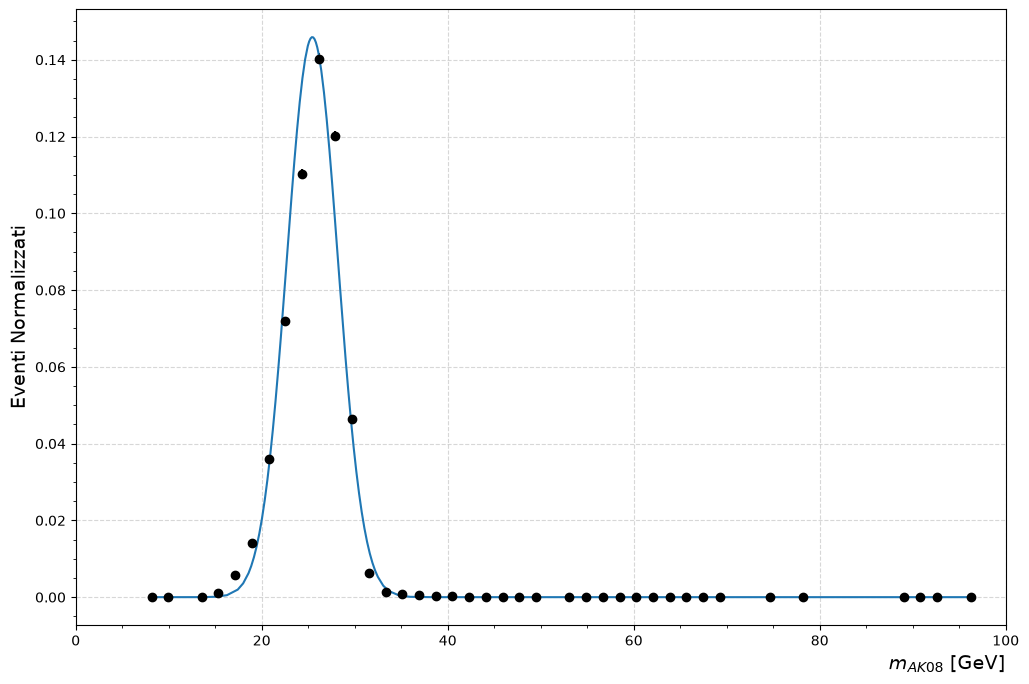

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.stats import chi2

# 1. Assicurati che len(x_easy) sia la variabile giusta per la normalizzazione
# (Nel tuo codice usavi len(x_plot), se sono array diversi sballa la scala)
x_easy=x_easy=[x for x in x if 0<x<100]

N_tot = len(x_easy) 

bin_counts, bin_edges = np.histogram(x_easy, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# 2. MASCHERA: Prendi solo i bin con più di 0 conteggi
mask = bin_counts > 0

valid_centers = bin_centers[mask]
valid_counts = bin_counts[mask]

# Normalizzazione applicata solo ai bin validi
valid_densities = valid_counts / (N_tot * bin_width)
valid_yerr = np.sqrt(valid_counts) / (N_tot * bin_width)

# 3. Ridefinisci la tua funzione gaussiana per includere l'Ampiezza (A)
from numba_stats import truncnorm
x_range=(0, max(x_easy))

def gaussiana(x, mu, sigma):
    return truncnorm.pdf(x, *x_range, loc=mu, scale=sigma)


# Passa i dati mascherati al LeastSquares
ls_gauss = LeastSquares(valid_centers, valid_densities, valid_yerr, model=gaussiana)

# 4. Inizializza Minuit con il nuovo parametro A
# Guess iniziale per A: approssimativamente l'area del picco (es. 0.5 se è il 50% dei dati)
m_gauss = Minuit(ls_gauss, mu=25, sigma=3)
m_gauss.limits["mu"] = (10, 40)
m_gauss.limits["sigma"] = (0.1, 20)

m_gauss.migrad()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 8))

# Minuit.visualize() plota automaticamente il modello sovrapposto ai dati passati al cost function
m_gauss.visualize()

ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(0, 100)
ax.grid(True, linestyle='--', alpha=0.5)

# plt.savefig('...', bbox_inches='tight')

# --- Stampe ---
print(m_gauss.values)
print(f"chi2 = {m_gauss.fval:.3f}")
print(f"ndof = {m_gauss.ndof}")
print(f"chi2/ndof = {m_gauss.fval / m_gauss.ndof:.3f}")

p_value = chi2.sf(m_gauss.fval, m_gauss.ndof)
print(f"p-value = {p_value:.3e}")

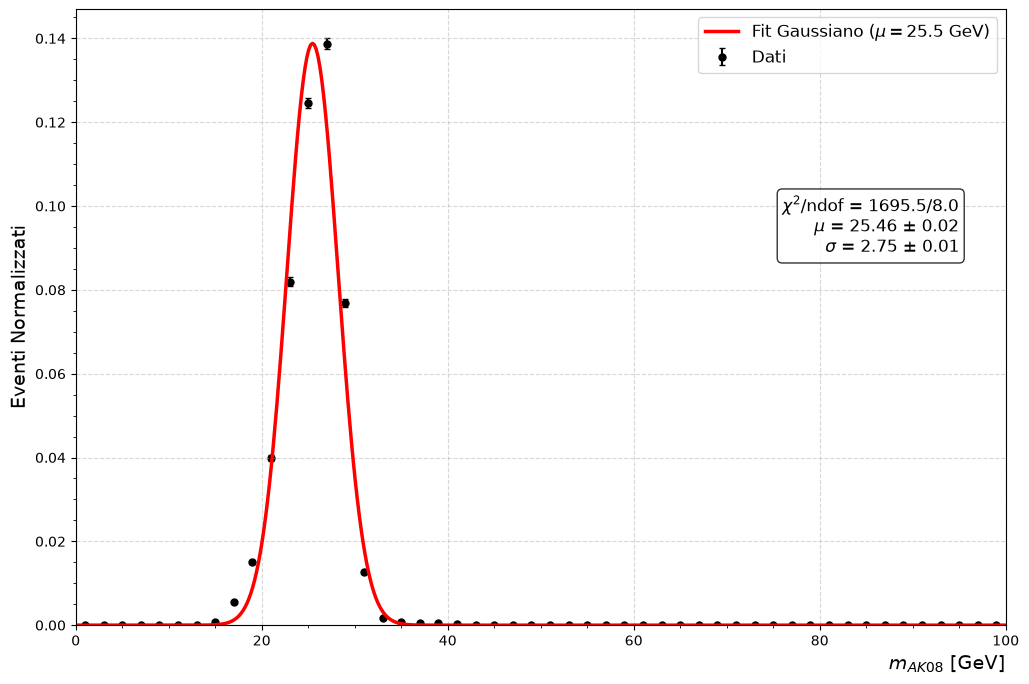

chi2 = 1695.541
ndof = 8.0
p-value = 0.000e+00


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.stats import chi2

# --- 1. PREPARAZIONE DATI E FIT ---
N_tot = len(x_easy)
bin_counts, bin_edges = np.histogram(x_easy, bins=50, range=(0, 100))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Densità e incertezze su TUTTO l'istogramma (servono per il plot)
bin_densities = bin_counts / (N_tot * bin_width)
yerr = np.sqrt(bin_counts) / (N_tot * bin_width)

# MASCHERA: Applichiamo la maschera SOLO per il calcolo del fit (es. range 15-35 e no zeri)
mask = (bin_counts > 0) & (bin_centers >= 15) & (bin_centers <= 35)

def gaussiana(x, A, mu, sigma):
    return A * (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Fit solo sui dati mascherati
ls_gauss = LeastSquares(bin_centers[mask], bin_densities[mask], yerr[mask], model=gaussiana)
m_gauss = Minuit(ls_gauss, A=0.1, mu=25, sigma=3)
m_gauss.limits["mu"] = (10, 40)
m_gauss.limits["sigma"] = (0.1, 20)
m_gauss.limits["A"] = (0, 1)
m_gauss.migrad()


# --- 2. PLOT MANUALE (La soluzione per un bel grafico) ---
fig, ax = plt.subplots(figsize=(12, 8))

# A) Disegna i dati originali completi (da 0 a 100 GeV) con punti ed errorbar
ax.errorbar(bin_centers, bin_densities, yerr=yerr, fmt='ko', markersize=5, 
            capsize=2, label='Dati', zorder=1)

# B) Disegna la curva di fit in modo fluido su tutto l'asse X
# Creiamo un array di x fittissimo (500 punti) per una curva liscia
x_smooth = np.linspace(0, 100, 500)
# Usiamo *m_gauss.values per passare automaticamente i parametri ottimali alla funzione
y_smooth = gaussiana(x_smooth, *m_gauss.values)

# Disegniamo la curva del modello
ax.plot(x_smooth, y_smooth, color='red', linewidth=2.5, 
        label=rf'Fit Gaussiano ($\mu={m_gauss.values["mu"]:.1f}$ GeV)', zorder=2)

# --- 3. STILE DEL GRAFICO ---
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(0, 100)
# Opzionale: fissa un limite y minimo per vedere bene anche gli zeri, es. bottom=0
ax.set_ylim(bottom=0) 
ax.grid(True, linestyle='--', alpha=0.5)

# Aggiungiamo un box informativo con il Chi2 e i parametri (molto utile per la tesi)
# Aggiunta la 'r' davanti a ogni f-string (rf"...")
fit_info = (rf"$\chi^2$/ndof = {m_gauss.fval:.1f}/{m_gauss.ndof}" + "\n" +
            rf"$\mu$ = {m_gauss.values['mu']:.2f} $\pm$ {m_gauss.errors['mu']:.2f}" + "\n" +
            rf"$\sigma$ = {m_gauss.values['sigma']:.2f} $\pm$ {m_gauss.errors['sigma']:.2f}")
ax.text(0.95, 0.7, fit_info, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.legend(loc="upper right", fontsize=12)

# plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Gauss_Minuit_25', bbox_inches='tight')
plt.show()

# Stampa a schermo
print(f"chi2 = {m_gauss.fval:.3f}")
print(f"ndof = {m_gauss.ndof}")
print(f"p-value = {chi2.sf(m_gauss.fval, m_gauss.ndof):.3e}")